100000


Text(0, 0.5, 'Counts')

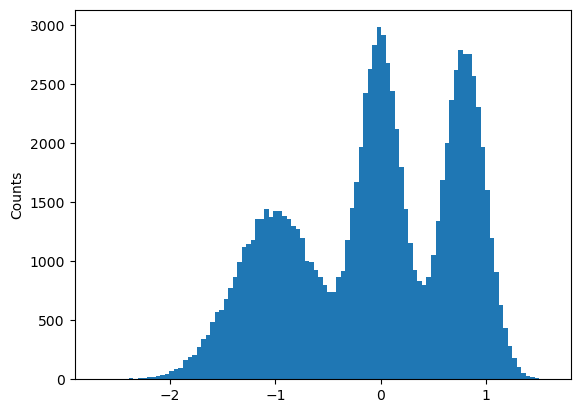

In [142]:
import sys
import os
import tqdm
import math
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sys.path.append("..")

import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def single_gauss(x, x0, sig):
    return 1/(np.sqrt(2*np.pi)*sig)*np.exp(-(x-x0)**2/2/sig**2)

def triple_gauss(x, x0, y0, z0, sig1, sig2, sig3):
    return (single_gauss(x, x0, sig1) + single_gauss(x, y0, sig2)+ single_gauss(x, z0, sig3))/3
# Parameters
N = 100000  # Number of points to sample
x_min, x_max = -4, 4
resolution = 100  # Resolution of the grid

# Create the grid
x = np.linspace(x_min, x_max, resolution)
true_func = triple_gauss(x, -2, 1, 3, 0.2, 0.5, 0.3)
sampled_points = []
while len(sampled_points) < N:
    samp_x = np.random.uniform(low=-5, high=5)
    samp_y = np.random.uniform()
    if triple_gauss(samp_x, -1, 0, 0.8, 0.4, 0.2, 0.2) > samp_y:
        sampled_points.append(samp_x)
# Convert to NumPy array for easier plotting
sampled_points = np.array(sampled_points)


print(len(sampled_points))
fig, ax = plt.subplots()
ax.hist(sampled_points, bins=100)
# Plot sampled points
ax.set_xlabel("")
ax.set_ylabel("Counts")

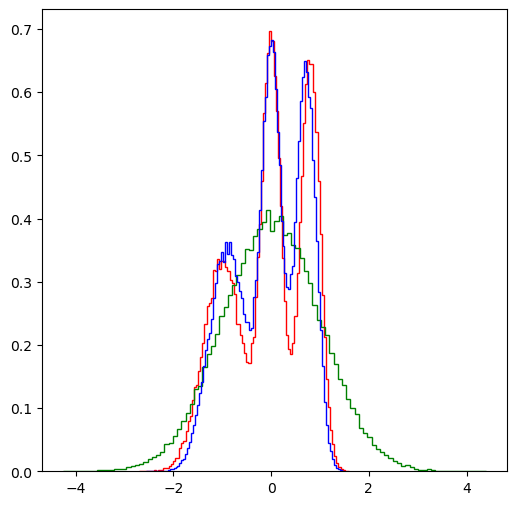

In [143]:
t = 0.9
noise = np.random.randn(N)
plt.figure(figsize=(6, 6))
plt.hist(sampled_points, histtype="step", color="red", bins=100, density=True)
plt.hist(noise, histtype="step", color="green", bins=100, density=True)
plt.hist((1 - t) * noise + t * sampled_points, histtype="step", color="blue", bins=100, density=True)
# plt.scatter(noise[:, 0], noise[:, 1], color="blue", marker="o")
# plt.scatter((1 - t) * noise[:, 0] + t * sampled_points[:, 0], (1 - t) * noise[:, 1] + t * sampled_points[:, 1], color="green", marker="o")
plt.show()

In [144]:
class Block(nn.Module):
    def __init__(self, channels=512):
        super().__init__()
        self.ff = nn.Linear(channels, channels)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.ff(x))

class MLP(nn.Module):
    def __init__(self, channels_data=1, layers=5, channels=512, channels_t=512):
        super().__init__()
        self.channels_t = channels_t
        self.in_projection = nn.Linear(channels_data, channels)
        self.t_projection = nn.Linear(channels_t, channels)
        self.blocks = nn.Sequential(*[
            Block(channels) for _ in range(layers)
        ])
        self.out_projection = nn.Linear(channels, channels_data)

    def gen_t_embedding(self, t, max_positions=10000):
        t = t * max_positions
        half_dim = self.channels_t // 2
        emb = math.log(max_positions) / (half_dim - 1)
        emb = torch.arange(half_dim, device=t.device).float().mul(-emb).exp()
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        if self.channels_t % 2 == 1:  # zero pad
            emb = nn.functional.pad(emb, (0, 1), mode='constant')
        return emb

    def forward(self, x, t):
        x = self.in_projection(x)
        t = self.gen_t_embedding(t)
        t = self.t_projection(t)
        x = x + t 
        x = self.blocks(x)
        x = self.out_projection(x)
        return x

In [145]:

model = MLP(layers=10, channels=256)
optim = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [151]:
data = torch.Tensor(sampled_points)
data = data.unsqueeze(1)
training_steps = 100_000
batch_size = 128
pbar = tqdm.tqdm(range(training_steps))
losses = []
for i in pbar:
    x1 = data[torch.randint(data.size(0), (batch_size,))]
    x0 = torch.randn_like(x1)
    target = x1 - x0
    t = torch.rand(x1.size(0))
    xt = (1 - t[:, None]) * x0 + t[:, None] * x1
    pred = model(xt, t)  # also add t here
    loss = ((target - pred)**2).mean()
    loss.backward()
    optim.step()
    optim.zero_grad()
    pbar.set_postfix(loss=loss.item())
    losses.append(loss.item())

100%|██████████| 100000/100000 [11:11<00:00, 148.97it/s, loss=1.25]


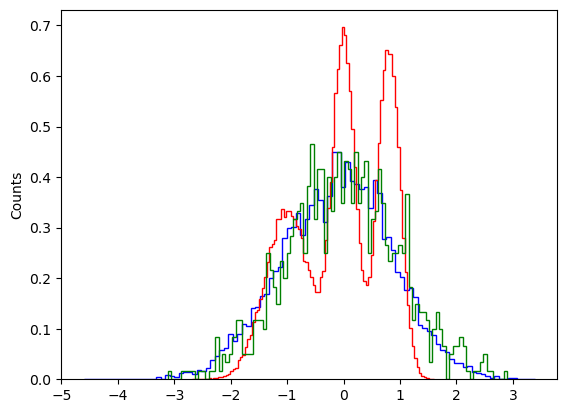

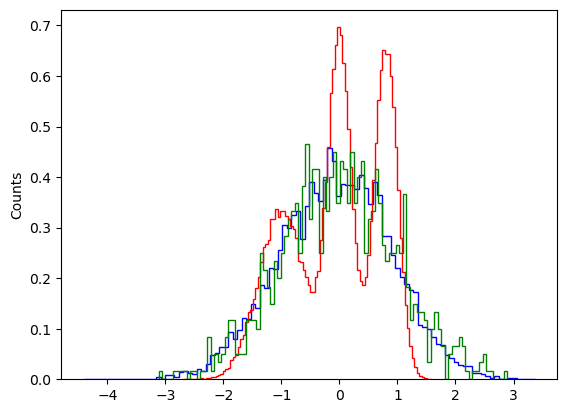

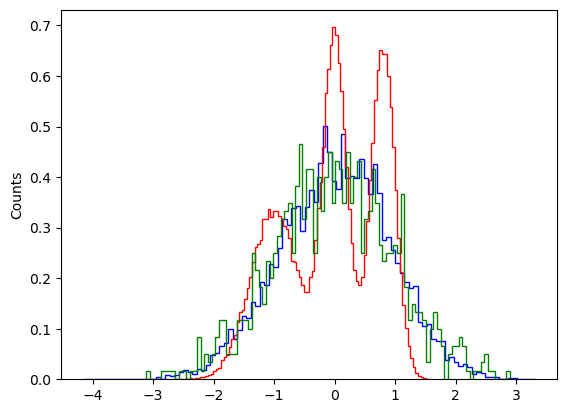

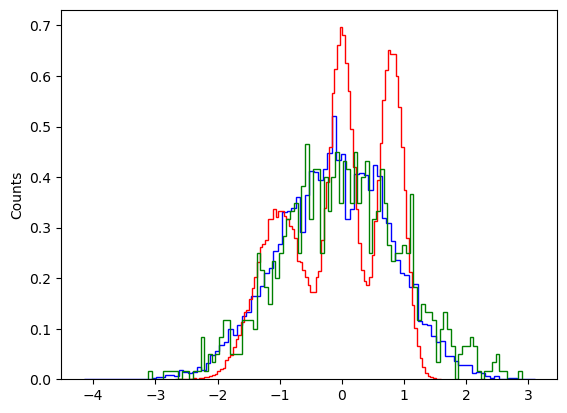

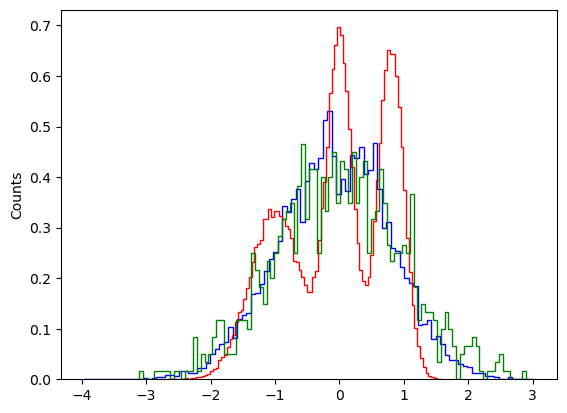

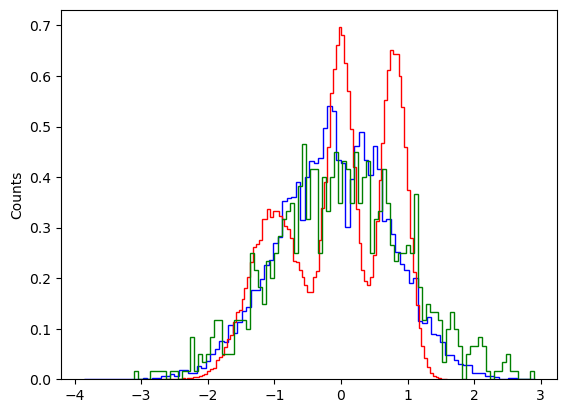

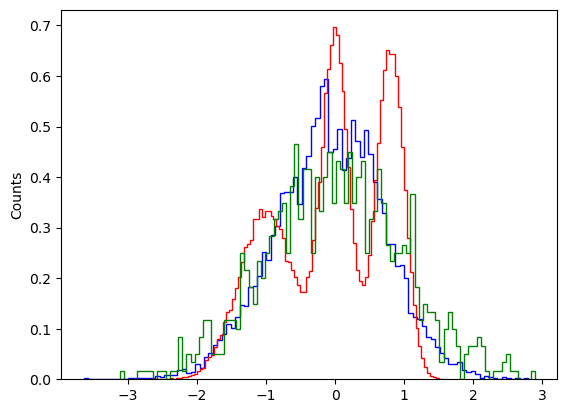

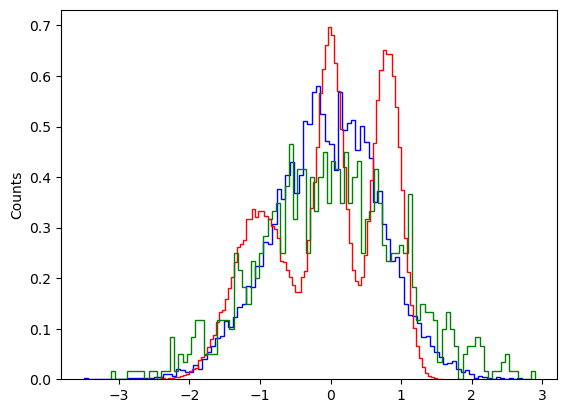

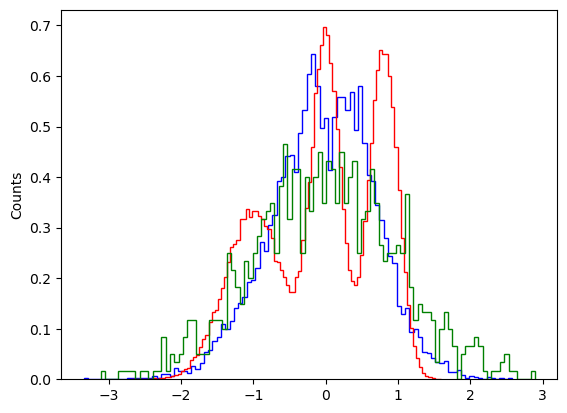

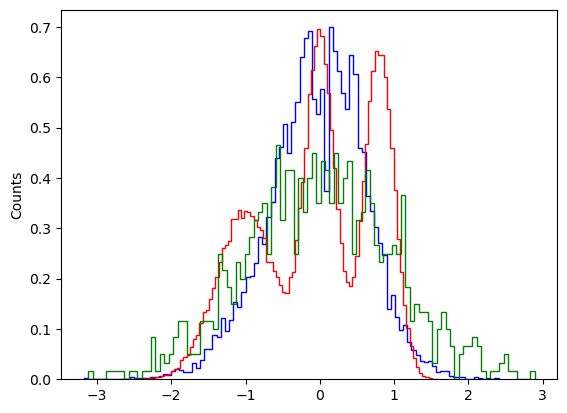

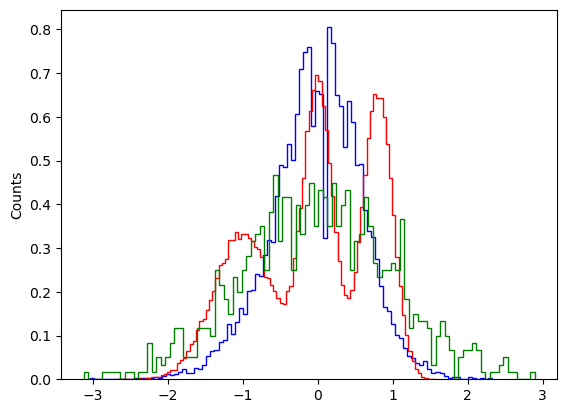

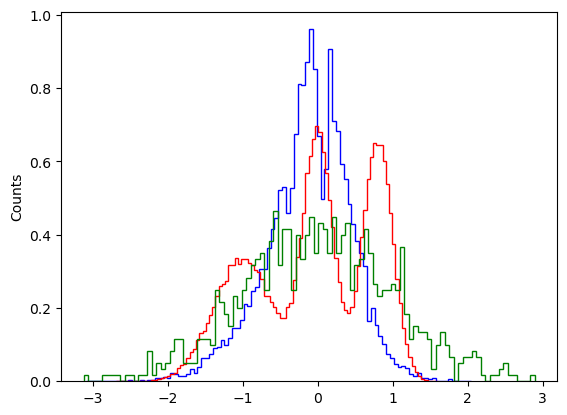

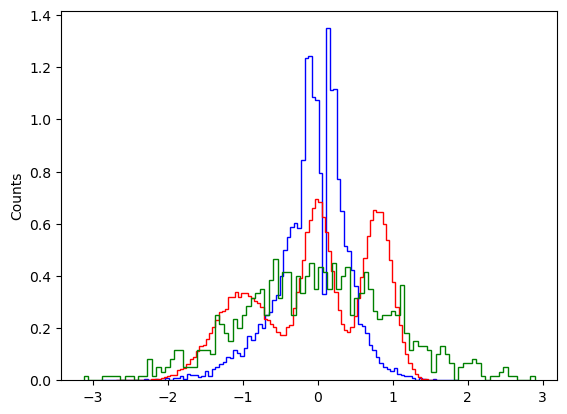

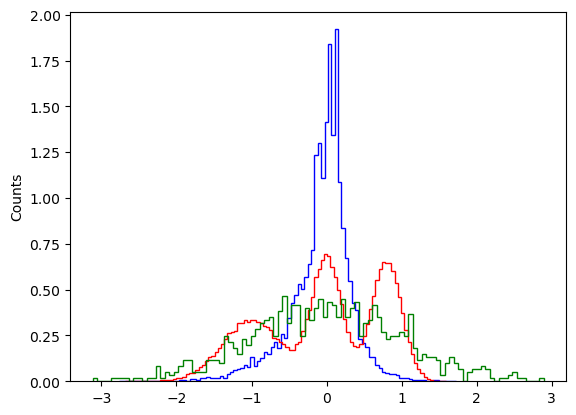

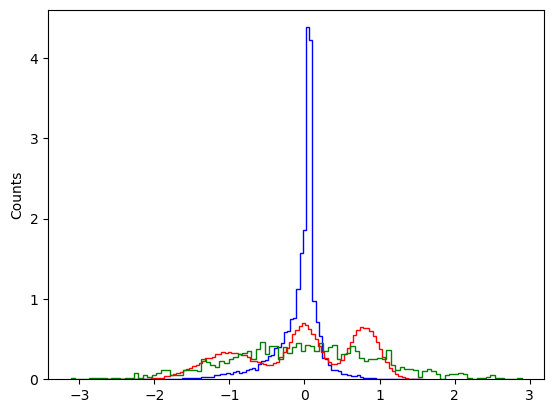

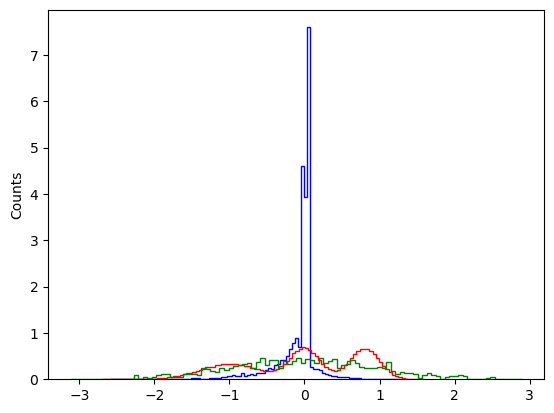

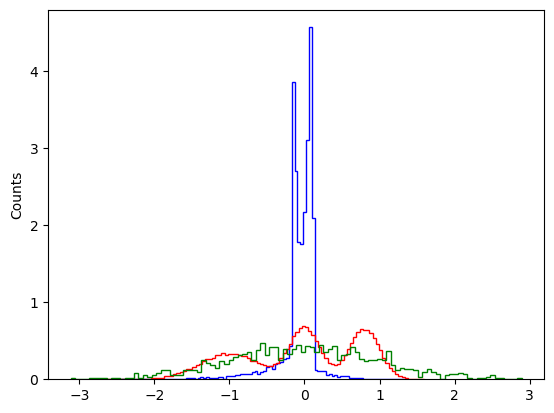

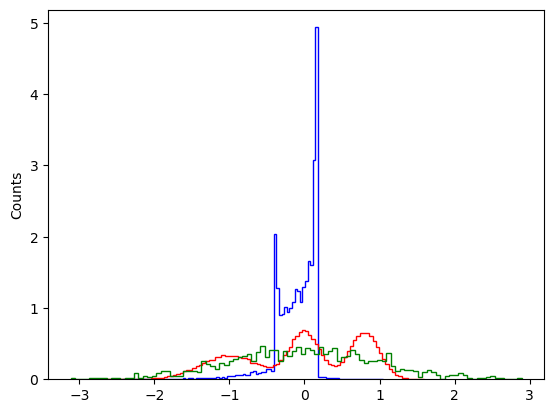

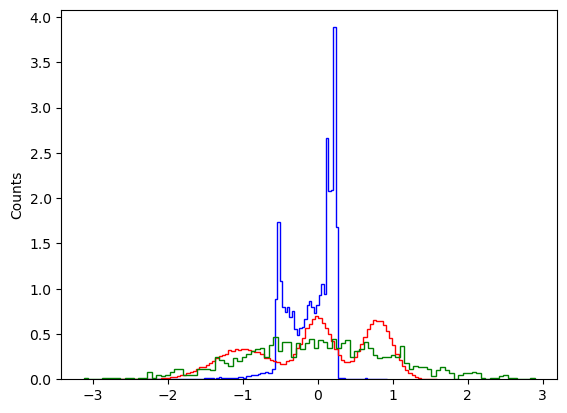

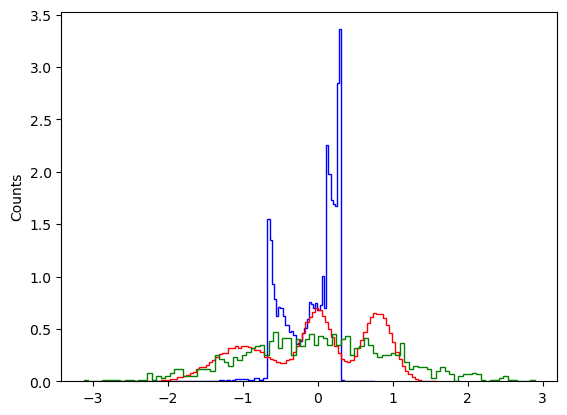

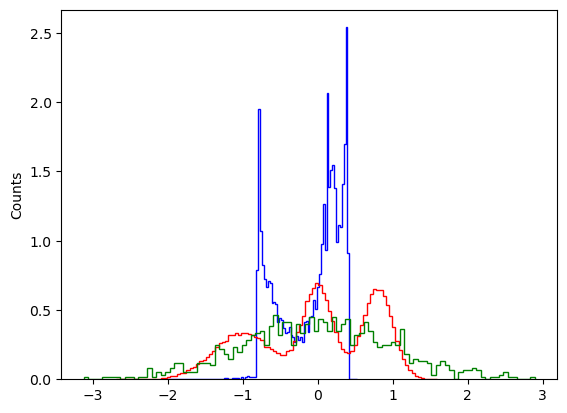

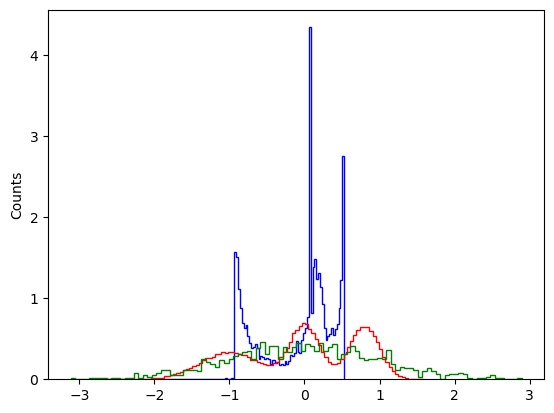

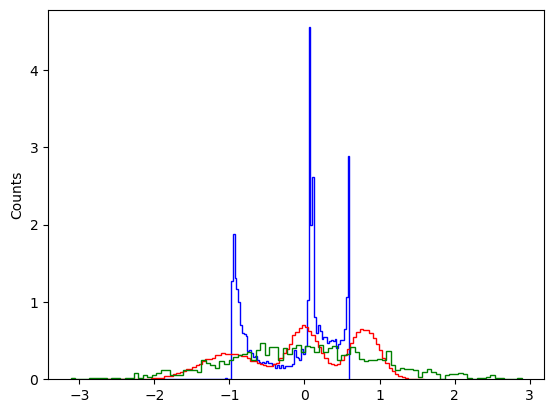

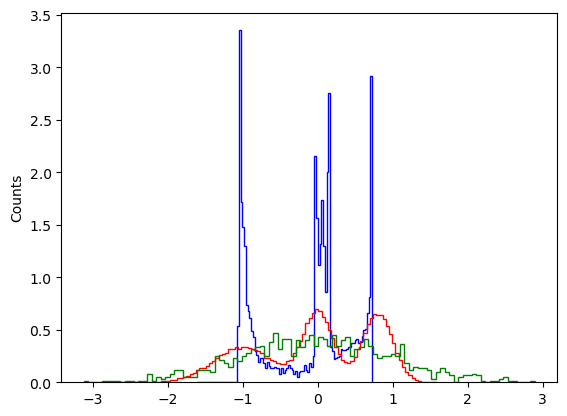

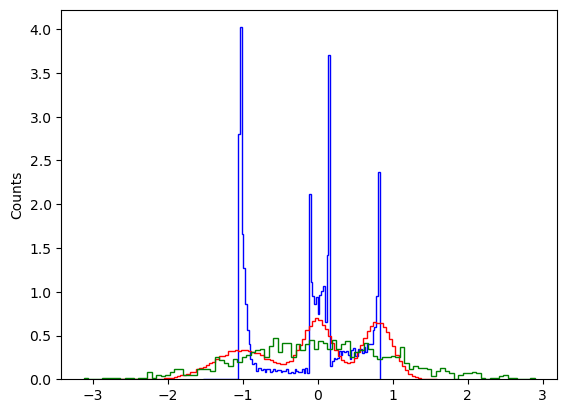

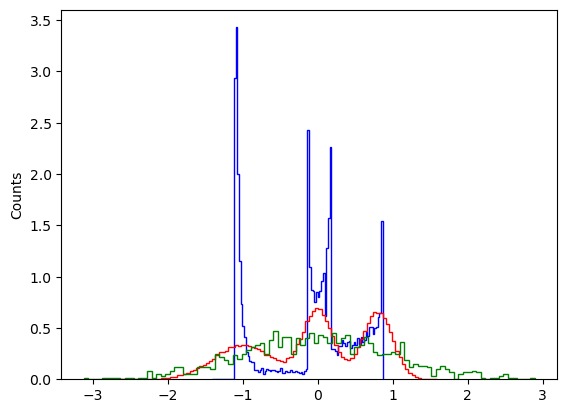

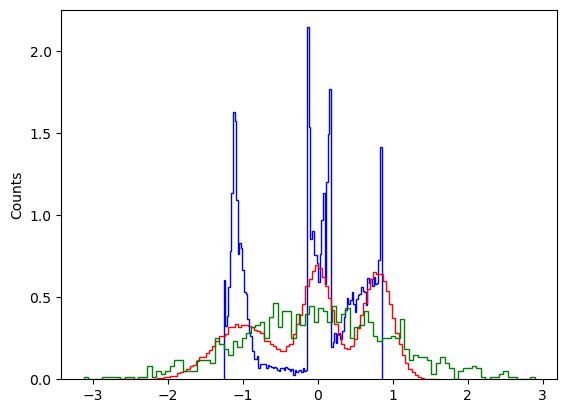

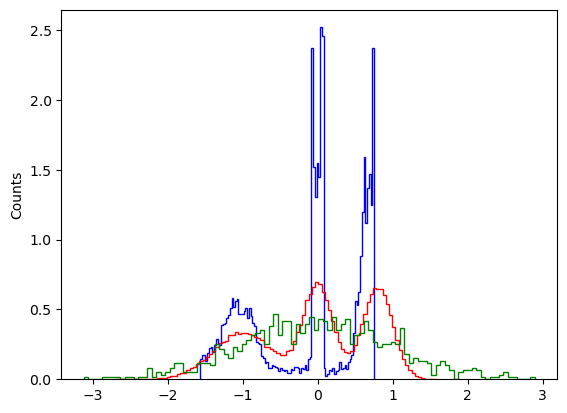

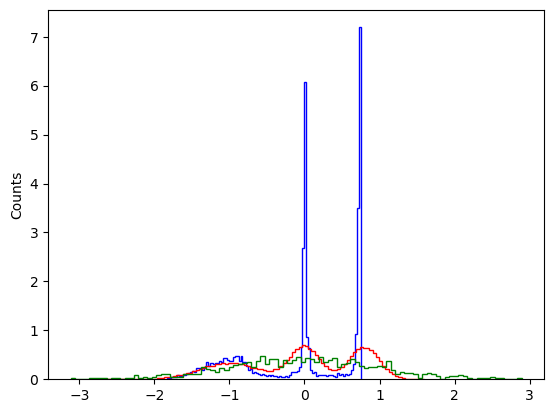

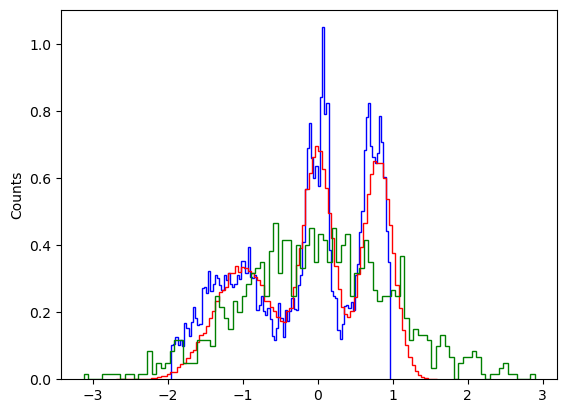

Done Sampling


In [180]:
torch.manual_seed(42)
model.eval().requires_grad_(False)
xt = torch.randn(10000, 1)
xt_t = []
steps = 10000
plot_every = 333
noise = np.random.randn(N)
for i, t in enumerate(torch.linspace(0, 1, steps), start=1):
    pred = model(xt, t.expand(xt.size(0)))
    xt_t.append(pred)
    xt = xt + (1 / steps) * pred
    if i % plot_every == 0:
        fig, ax = plt.subplots()
        ax.hist(pred, histtype="step", color="blue", bins=100, density=True)
        ax.hist(sampled_points, histtype="step", color="red", bins=100, density=True)
        ax.hist(noise, histtype="step", color="green", bins=100, density=True)
        # Plot sampled points
        ax.set_xlabel("")
        ax.set_ylabel("Counts")
        plt.show()
model.train().requires_grad_(True)
print("Done Sampling")
xt_t = torch.hstack(xt_t)

Yello


/var/folders/m8/f330x_5d5lvdrkc5f7qn2b1h0000gn/T/ipykernel_6064/849904142.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


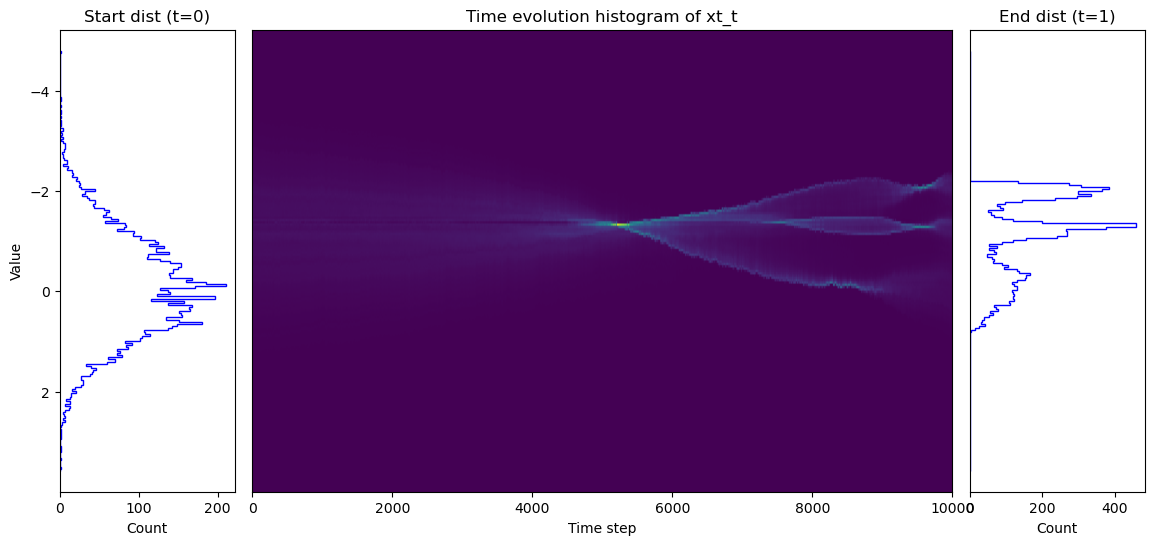

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

T, N = xt_t.shape

# choose number of histogram bins
num_bins = 200
bins = np.linspace(xt_t.min(), xt_t.max(), num_bins + 1)

# histogram array: (N, num_bins)
hist = np.zeros((N, num_bins))

for i in range(N):
    hist[i], _ = np.histogram(xt_t[:, i], bins=bins)

print("Yello")

# ---- New Figure Layout ----
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 4, 1], wspace=0.05)

# Left histogram (time = 0)
ax_left = fig.add_subplot(gs[0])
ax_left.hist(xt_t[:, 0], bins=bins, orientation='horizontal', color='blue', histtype="step")
ax_left.set_title("Start dist (t=0)")
ax_left.set_ylabel("Value")
ax_left.set_xlabel("Count")
ax_left.invert_yaxis()

# Main heatmap
ax_main = fig.add_subplot(gs[1])
im = ax_main.imshow(
    hist.T,
    aspect='auto',
    origin='lower',
    extent=[0, N, bins[0], bins[-1]],
    interpolation="auto"
)
ax_main.set_title("Time evolution histogram of xt_t")
ax_main.set_xlabel("Time step")
ax_main.set_yticks([]) 

# Right histogram (time = final)
ax_right = fig.add_subplot(gs[2])
ax_right.hist(xt_t[:, -1], bins=bins, orientation='horizontal', color='blue', histtype="step", label="Generated sample")
ax_right.hist(sampled_points, bins=bins, orientation="horizontal", color='red', histtype="step", label="Target distribution")
ax_right.set_title("End dist (t=1)")
ax_right.set_xlabel("Count")
ax_right.set_yticks([])  # remove duplicate y-axis

plt.tight_layout()
plt.show()
